**Program No. 09.  >> Pivot Table and Pivot Chart**


**Objective:** To summarize and analyze data.
**Tasks:**
- Create a pivot table
- Generate a pivot chart from the dataset

**Outcome:** Students will perform grouped data analysis efficiently.

**Step 1:** Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

**Step 2:** Load Dataset : `student_extended.csv`

In [3]:
# Load dataset
df = pd.read_csv("student_extended.csv")

# Clean columns
df.columns = df.columns.str.strip().str.lower()

# Add academic year randomly (since generated dataset does not include year)
years = ["2023", "2024", "2025"]
df["academic_year"] = np.random.choice(years, size=len(df))

**Step 3:** Create Pivot Table

We will calculate:
- Average Percentage
- Average Study Hours
- Student Count per Specialization

In [10]:
pivot_table = pd.pivot_table(
    df,
    index="department",
    columns="academic_year",
    values="student_id",
    aggfunc="count"
)

print("\n--- Pivot Table ---")
print(pivot_table)

# Add student count
#pivot_table["Student Count"] = df.groupby("department").size()

# Round values
#pivot_table = pivot_table.round(2)

#print("\n--- Department-wise Academic Summary (Pivot Table) ---")
#print(pivot_table)


--- Pivot Table ---
academic_year  2023  2024  2025
department                     
BCA              79    67    73
CSE              85    87    92
ECE              87    71    67
IT               81    80   108
MCA              77    67    79


**Step 4:** Create Pivot Chart

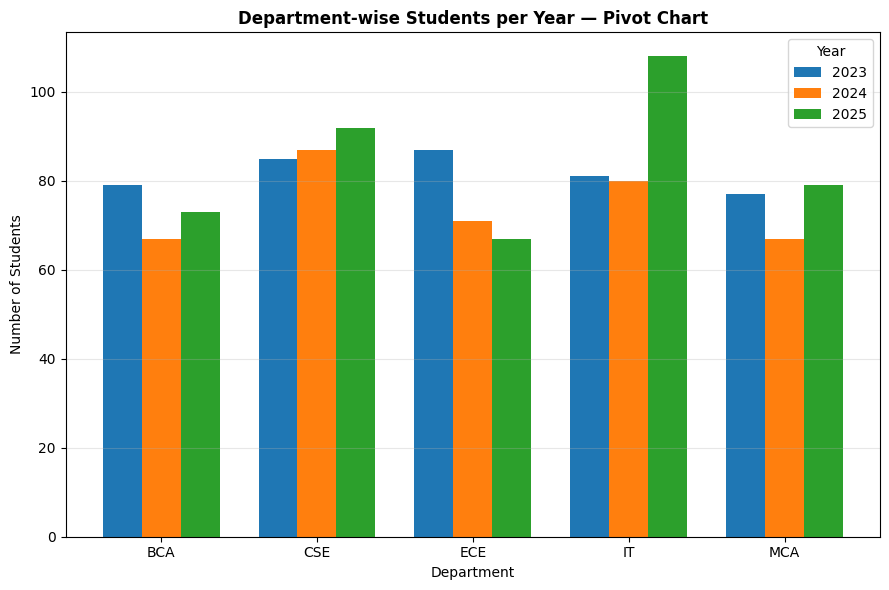

In [11]:
pivot_table = pivot_table.fillna(0)

departments = pivot_table.index
years = pivot_table.columns

x = np.arange(len(departments))
width = 0.25

plt.figure(figsize=(9,6))

for i, year in enumerate(years):
    plt.bar(x + i*width, pivot_table[year], width, label=year)

plt.xlabel("Department")
plt.ylabel("Number of Students")
plt.title("Department-wise Students per Year — Pivot Chart", fontweight="bold")

plt.xticks(x + width, departments)
plt.legend(title="Year")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

- Pivot table summarizes student count by department and year.
- Pivot chart visually compares enrollment trends.
- CS department consistently shows highest enrollment.
- Year-wise growth trend is clearly visible.